# Langgraph – wprowadzenie i LLMy – zadania

Dane do ćwiczeń: plik `recenzje.json` obejmuje 10 recenzji filmowych (pozytywne, neutralne, negatywne).

Zbudujesz pipeline analizujący recenzję filmową: rozbija tekst na słowa, oblicza statystyki, ocenia sentyment przez LLM i formatuje końcowy raport.

## Stan (TypedDict)

1. Zdefiniuj `State` dla pipeline'u. Stan powinien zawierać pola:
- `raw_text: str` – surowy tekst recenzji
- `sentiment: str` – ocena sentymentu zwrócona przez LLM

---
(czas: 5 min.)

In [1]:
from typing import TypedDict

class State(TypedDict):
    raw_text: str
    sentiment: str

## Node'y

2. Napisz node `extract_words_node(state: State)`, który rozbija `raw_text` na listę słów i zapisuje wynik do `words`.

---
(czas: 3 min.)

In [ ]:
# ...

3. Napisz node `count_statistics_node(state: State)`, który na podstawie listy `words` oblicza `word_count` (łączna liczba słów) oraz `unique_count` (liczba unikalnych słów).

---
(czas: 3 min.)

In [ ]:
# ...

4. Napisz node `analyze_sentiment_node(state: State, config: RunnableConfig)`, który:
- odczytuje `model_name` (domyślnie `"openai/gpt-4o-mini"`) i `temperature` (domyślnie `0.0`) z `configurable`
- buduje prompt z wiadomością `system` i wiadomością `user` zawierającą `raw_text` recenzji
- wywołuje `ChatOpenAI` i zapisuje odpowiedź do pola `sentiment`

Sentyment powinien być pozytywny, neutralny lub negatywny.

---
(czas: 8 min.)

In [2]:
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI

In [3]:
load_dotenv()

True

In [4]:
def analyze_sentiment_node(state: State, config: RunnableConfig):
    configurable = config["configurable"]
    model_name = configurable["model_name"] 
    temperature = configurable["temperature"] 

    llm = ChatOpenAI(model=model_name, temperature=temperature)
    messages = [
        {"role": "system", "content": "Evaluate the sentiment of the movie review. Reply with a single word: pozytywna, neutralna or negatywna."},
        {"role": "user", "content": state["raw_text"]}
    ]
    response = llm.invoke(messages)
    return {"sentiment": response.content}

5. Napisz node `build_report_node(state: State)`, który zbiera dane ze stanu i formatuje czytelny tekst raportu zapisywany do `report`. Raport powinien zawierać co najmniej: fragment recenzji, liczbę słów, liczbę unikalnych słów i ocenę sentymentu.

---
(czas: 5 min.)

In [ ]:
# ...

## Graf

6. Zbuduj `StateGraph(State)`. Dodaj wszystkie cztery node'y i połącz je krawędziami.

Skompiluj pipeline i wyświetl jego wizualizację.

---
(czas: 8 min.)

In [9]:
from langgraph.graph import StateGraph, START, END

In [10]:
graph = StateGraph(State)

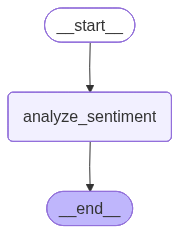

In [11]:
graph.add_node("analyze_sentiment", analyze_sentiment_node)

graph.add_edge(START, "analyze_sentiment")
graph.add_edge("analyze_sentiment", END)

pipeline = graph.compile()

pipeline

In [12]:
import json

In [13]:
with open("recenzje.json", "r") as f:
    reviews = json.load(f)

In [19]:
review_text = reviews[0]["recenzja"]
review_text

'Absolutne arcydzieło. Nolan po raz kolejny udowodnił, że potrafi tworzyć kino na najwyższym poziomie. Montaż, muzyka i gra aktorska wciągają bez reszty przez trzy godziny. Jeden z najlepszych filmów dekady.'

In [20]:
runtime_config = {
    "configurable": {
        "model_name": "openai/gpt-4o-mini",
        "temperature": 0
    }
}

result = pipeline.invoke({"raw_text": review_text}, config=runtime_config)

In [21]:
result

{'raw_text': 'Absolutne arcydzieło. Nolan po raz kolejny udowodnił, że potrafi tworzyć kino na najwyższym poziomie. Montaż, muzyka i gra aktorska wciągają bez reszty przez trzy godziny. Jeden z najlepszych filmów dekady.',
 'sentiment': 'pozytywna'}

## Uruchomienie

7. Uruchom pipeline za pomocą `invoke` na wybranej recenzji z pliku `recenzje.json`. Zdefiniuj `runtime_config` z `model_name` i `temperature`. Wypisz `report` z wyniku.

---
(czas: 8 min.)

In [ ]:
# ...

8. Wczytaj plik `recenzje.json` i uruchom pipeline na wszystkich 10 recenzjach w pętli. Wypisz dla każdej z nich tytuł, oczekiwany sentyment z pliku JSON i sentyment zwrócony przez LLM. Sprawdź ile razy model się pomylił.

Jeśli zdążysz – zmień `system_prompt` i sprawdź czy model radzi sobie lepiej lub gorzej przy innym sformułowaniu instrukcji.

---
(czas: 10 min.)

In [23]:
errors = 0
for review in reviews:
    result = pipeline.invoke({"raw_text": review["recenzja"]}, config=runtime_config)
    expected = review["sentyment"]
    llm_result = result["sentiment"]

    match = "OK" if expected == llm_result else "ERROR"
    if match == "ERROR":
        errors += 1
    print(f"{review['tytul']} | expected: {expected} | LLM: {llm_result} | match: {match}")

Oppenheimer | expected: pozytywna | LLM: pozytywna | match: OK
Barbie | expected: neutralna | LLM: neutralna | match: OK
Dune: Część druga | expected: neutralna | LLM: neutralna | match: OK
Maestro | expected: pozytywna | LLM: pozytywna | match: OK
Indiana Jones i artefakt przeznaczenia | expected: negatywna | LLM: negatywna | match: OK
Past Lives | expected: pozytywna | LLM: pozytywna | match: OK
Aquaman i Zaginione Królestwo | expected: negatywna | LLM: negatywna | match: OK
Beau ma się na baczności | expected: neutralna | LLM: neutralna | match: OK
Killers of the Flower Moon | expected: pozytywna | LLM: pozytywna | match: OK
The Flash | expected: negatywna | LLM: negatywna | match: OK


In [24]:
errors

0